# Benchmark: DLTS-DFS vs Beam Search

Ambos solvers usan el **mismo branching model** (`v9_dataBSG_250k`).

La diferencia está en la **estrategia de búsqueda**:
- **Greedy**: sigue siempre el movimiento más probable. Sin exploración.
- **Beam Search**: mantiene los W mejores estados (por log-probabilidad acumulada). Sin backtracking.
- **DLTS-DFS**: profundidad primero con backtracking, usa además el bounding model (`v2_cost`) para podar ramas.

El Beam Search usa **solo** el branching model (sin bounding model), para aislar
el efecto de la estrategia de búsqueda respecto a DLTS-DFS.

In [1]:
import sys, os, json, copy, time
import torch
import numpy as np

MAIN_SRC = os.path.abspath('../src')
REPO_SRC = os.path.abspath('../Repo_Oscar/CPMP-Framework/src')
MODEL_DIR = os.path.abspath('../models')

# Fase 1: main src (CPMPTransformer, solvers, cpmp)
sys.path.insert(0, MAIN_SRC)

from training.training import load_model
from models.cpmp_transformer_v9 import CPMPTransformer
from solvers.model import ModelSolver
from solvers.dlts_dfs import DLTSDFSSolver
from solvers.beam_search import BeamSearchSolver
from cpmp.layout import read_file
from settings import INSTANCE_FOLDER

print('Main src OK')

# Fase 2: limpiar generation y cargar Repo_Oscar (adapters del bounding model)
for k in [k for k in sys.modules if k == 'generation' or k.startswith('generation.')]:
    del sys.modules[k]
sys.path.insert(0, REPO_SRC)

from models.cost.cost_predictor_V2 import CostPredictorTransformer
from generation.adapters.input.enriched_layout_adapter import EnrichedLayoutAdapter
from generation.adapters.input.layout.layout_4D_adapter_V2 import Layout4DAdapterV2
from generation.adapters.input.stack_features.stack_features_adapter_V1 import StackFeaturesAdapterV1

print('Repo_Oscar OK')
print('Listo.')

Main src OK
Repo_Oscar OK
Listo.


In [2]:
# ── Cargar modelos ────────────────────────────────────────────────────────────
branching_model = load_model(CPMPTransformer, 'v9_dataBSG_250k')
branching_model.eval()

def load_cost_model(name):
    hp = json.load(open(os.path.join(MODEL_DIR, 'hyperparameters', f'{name}.json')))
    m = CostPredictorTransformer(**hp)
    m.load_state_dict(torch.load(os.path.join(MODEL_DIR, f'{name}.pth'),
                                  weights_only=True, map_location='cpu'))
    m.eval()
    return m

bounding_model = load_cost_model('v2_cost')

bounding_adapter = EnrichedLayoutAdapter(
    layout_adapter=Layout4DAdapterV2,
    stack_features_adapter=StackFeaturesAdapterV1,
    S_max=10, H_max=12
)

print(f'Branching: v9_dataBSG_250k   H={branching_model.hyperparams["H"]}')
print(f'Bounding : v2_cost  (solo DLTS-DFS lo usa)')

Branching: v9_dataBSG_250k   H=12
Bounding : v2_cost  (solo DLTS-DFS lo usa)


In [3]:
# ── Instanciar solvers ────────────────────────────────────────────────────────
T_LIM = 15.0  # tiempo límite por instancia (segundos)
W     = 32     # beam width

greedy_solver = ModelSolver(branching_model)

dlts_solver = DLTSDFSSolver(
    branching_model=branching_model,
    bounding_model=bounding_model,
    bounding_adapter=bounding_adapter,
    p=0.3, k=3, d=0.8, time_limit=T_LIM
)

beam_solver = BeamSearchSolver(
    branching_model=branching_model,
    beam_width=W,
    expansions_per_state=W,   # top-W movimientos por estado
    time_limit=T_LIM
)

print('Solvers listos:')
print(f'  Greedy     : ModelSolver  (solo branching model)')
print(f'  Beam Search: W={beam_solver.beam_width}, exp/estado={beam_solver.expansions_per_state}, time_limit={beam_solver.time_limit}s  (solo branching model)')
print(f'  DLTS-DFS   : p={dlts_solver.p}, k={dlts_solver.k}, d={dlts_solver.d}, time_limit={dlts_solver.time_limit}s  (branching + bounding model)')

Solvers listos:
  Greedy     : ModelSolver  (solo branching model)
  Beam Search: W=32, exp/estado=32, time_limit=15.0s  (solo branching model)
  DLTS-DFS   : p=0.3, k=3, d=0.8, time_limit=15.0s  (branching + bounding model)


In [4]:
# ── Utilidades ────────────────────────────────────────────────────────────────
def avg(vals, mask=None):
    data = [v for v, ok in zip(vals, mask or [True]*len(vals)) if ok]
    return sum(data) / len(data) if data else float('nan')

def run_solver(solver, files, H_inf, max_steps):
    solved_list, steps_list, time_list = [], [], []
    for path in files:
        layout = read_file(path, H_inf)
        t0 = time.perf_counter()
        try:
            solved, steps = solver.solve_from_layout(layout, H_inf, max_steps)
        except Exception:
            solved, steps = False, max_steps
        elapsed = time.perf_counter() - t0
        solved_list.append(solved)
        steps_list.append(steps)
        time_list.append(elapsed)
    return solved_list, steps_list, time_list

print('Utilidades definidas.')

Utilidades definidas.


## Benchmark por categorías CVS

In [5]:
CVS_PATH  = INSTANCE_FOLDER / 'benchmarks' / 'CVS'
MAX_STEPS = 100
N_PER_CAT = 20

ALL_CATS = sorted([d for d in os.listdir(CVS_PATH)
                   if (CVS_PATH / d).is_dir() and not d.startswith('10-')])

SEP = '-' * 120
print(f"{'Cat':>6} {'H':>3} {'S':>3}  "
      f"{'Greedy':>7} {'pasos':>6} {'t(s)':>6}  "
      f"{'DLTS-DFS':>8} {'pasos':>6} {'t(s)':>6}  "
      f"{'BeamW=5':>7} {'pasos':>6} {'t(s)':>6}  "
      f"{'DLTS>G':>6} {'Beam>G':>6} {'DLTS>B':>7}")
print(SEP)

all_results = {}

for folder_name in ALL_CATS:
    H_r, S_r = [int(x) for x in folder_name.split('-')]
    H_inf = H_r + 2
    folder_path = CVS_PATH / folder_name
    files = sorted([str(folder_path / f)
                    for f in os.listdir(folder_path) if f.endswith('.dat')])[:N_PER_CAT]
    if not files:
        continue

    s_g, st_g, t_g = run_solver(greedy_solver, files, H_inf, MAX_STEPS)
    s_d, st_d, t_d = run_solver(dlts_solver,   files, H_inf, MAX_STEPS)
    s_b, st_b, t_b = run_solver(beam_solver,   files, H_inf, MAX_STEPS)

    all_results[folder_name] = dict(
        s_g=s_g, st_g=st_g, t_g=t_g,
        s_d=s_d, st_d=st_d, t_d=t_d,
        s_b=s_b, st_b=st_b, t_b=t_b,
    )

    n = len(files)
    ng, nd, nb_ = sum(s_g), sum(s_d), sum(s_b)

    dlts_beats_g = sum(1 for ok_d, ok_g, pd, pg in zip(s_d, s_g, st_d, st_g)
                       if ok_d and ok_g and pd < pg)
    beam_beats_g = sum(1 for ok_b, ok_g, pb, pg in zip(s_b, s_g, st_b, st_g)
                       if ok_b and ok_g and pb < pg)
    dlts_beats_b = sum(1 for ok_d, ok_b, pd, pb in zip(s_d, s_b, st_d, st_b)
                       if ok_d and ok_b and pd < pb)

    print(f"{folder_name:>6} {H_r:>3} {S_r:>3}  "
          f"{ng:>3}/{n:<2} {avg(st_g,s_g):>6.1f} {avg(t_g,s_g):>6.3f}  "
          f"{nd:>3}/{n:<2} {avg(st_d,s_d):>6.1f} {avg(t_d,s_d):>6.2f}  "
          f"{nb_:>3}/{n:<2} {avg(st_b,s_b):>6.1f} {avg(t_b,s_b):>6.2f}  "
          f"{dlts_beats_g:>6} {beam_beats_g:>6} {dlts_beats_b:>7}")

print(SEP)

all_sg  = [s for r in all_results.values() for s in r['s_g']]
all_stg = [s for r in all_results.values() for s in r['st_g']]
all_sd  = [s for r in all_results.values() for s in r['s_d']]
all_std = [s for r in all_results.values() for s in r['st_d']]
all_sb  = [s for r in all_results.values() for s in r['s_b']]
all_stb = [s for r in all_results.values() for s in r['st_b']]
all_tg  = [s for r in all_results.values() for s in r['t_g']]
all_td  = [s for r in all_results.values() for s in r['t_d']]
all_tb  = [s for r in all_results.values() for s in r['t_b']]
n_tot = len(all_sg)

print(f"{'TOTAL':>6} {'':>3} {'':>3}  "
      f"{sum(all_sg):>3}/{n_tot:<2} {avg(all_stg,all_sg):>6.1f} {avg(all_tg,all_sg):>6.3f}  "
      f"{sum(all_sd):>3}/{n_tot:<2} {avg(all_std,all_sd):>6.1f} {avg(all_td,all_sd):>6.2f}  "
      f"{sum(all_sb):>3}/{n_tot:<2} {avg(all_stb,all_sb):>6.1f} {avg(all_tb,all_sb):>6.2f}")

   Cat   H   S   Greedy  pasos   t(s)  DLTS-DFS  pasos   t(s)  BeamW=5  pasos   t(s)  DLTS>G Beam>G  DLTS>B
------------------------------------------------------------------------------------------------------------------------


/mnt/data/Proyectos/Universidad/CPMP-Transformer/.venv/lib/python3.14/site-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


   3-3   3   3   20/20   11.8  0.015   20/20   10.7   0.06   20/20   10.1   0.35      12     16       0
   3-4   3   4   20/20   10.2  0.012   20/20    9.3   0.07   20/20    8.9   0.33      11     15       1
   3-5   3   5   20/20   13.4  0.017   20/20   11.0   0.31   20/20   11.1   0.51      13     14       5
   3-6   3   6   20/20   14.3  0.018   20/20   12.6   2.20   20/20   12.9   0.69      16     11       8
   3-7   3   7   20/20   16.1  0.020   20/20   13.8   5.36   20/20   14.5   0.88      19     14      12
   3-8   3   8   20/20   16.8  0.021   20/20   14.6  10.42   20/20   14.8   0.95      16     16       9
   4-4   4   4   20/20   20.8  0.025   20/20   17.4   0.46   20/20   16.5   0.68      12     14       1
   4-5   4   5   20/20   20.6  0.025   20/20   18.8   1.95   20/20   18.6   0.90      16     15       3
   4-6   4   6   20/20   22.5  0.028   20/20   19.6   7.82   20/20   19.6   1.10      19     18       4
   4-7   4   7   20/20   25.9  0.032   20/20   23.6  11.66   20/

## Resumen numérico

In [6]:
# Solo instancias donde los 3 resolvieron
mask3 = [a and b and c for a, b, c in zip(all_sg, all_sd, all_sb)]
n3 = sum(mask3)

st_g3 = [s for s, ok in zip(all_stg, mask3) if ok]
st_d3 = [s for s, ok in zip(all_std, mask3) if ok]
st_b3 = [s for s, ok in zip(all_stb, mask3) if ok]

print(f'Instancias donde los 3 solvers resolvieron: {n3}')
print()
print(f'  Greedy     : avg pasos = {np.mean(st_g3):.2f}')
print(f'  DLTS-DFS   : avg pasos = {np.mean(st_d3):.2f}  ({(np.mean(st_d3)/np.mean(st_g3)-1)*100:+.1f}% vs greedy)')
print(f'  Beam Search: avg pasos = {np.mean(st_b3):.2f}  ({(np.mean(st_b3)/np.mean(st_g3)-1)*100:+.1f}% vs greedy)')
print()

d_beats_b = sum(1 for d, b in zip(st_d3, st_b3) if d < b)
b_beats_d = sum(1 for d, b in zip(st_d3, st_b3) if b < d)
equal     = sum(1 for d, b in zip(st_d3, st_b3) if d == b)
print(f'DLTS-DFS vs Beam Search (en las {n3} instancias comunes):')
print(f'  DLTS mejor : {d_beats_b:>4} ({d_beats_b/n3:>5.1%})')
print(f'  Igual       : {equal:>4} ({equal/n3:>5.1%})')
print(f'  Beam mejor  : {b_beats_d:>4} ({b_beats_d/n3:>5.1%})')

Instancias donde los 3 solvers resolvieron: 380

  Greedy     : avg pasos = 30.44
  DLTS-DFS   : avg pasos = 27.08  (-11.0% vs greedy)
  Beam Search: avg pasos = 26.78  (-12.0% vs greedy)

DLTS-DFS vs Beam Search (en las 380 instancias comunes):
  DLTS mejor :  122 (32.1%)
  Igual       :  135 (35.5%)
  Beam mejor  :  123 (32.4%)


## Visualización

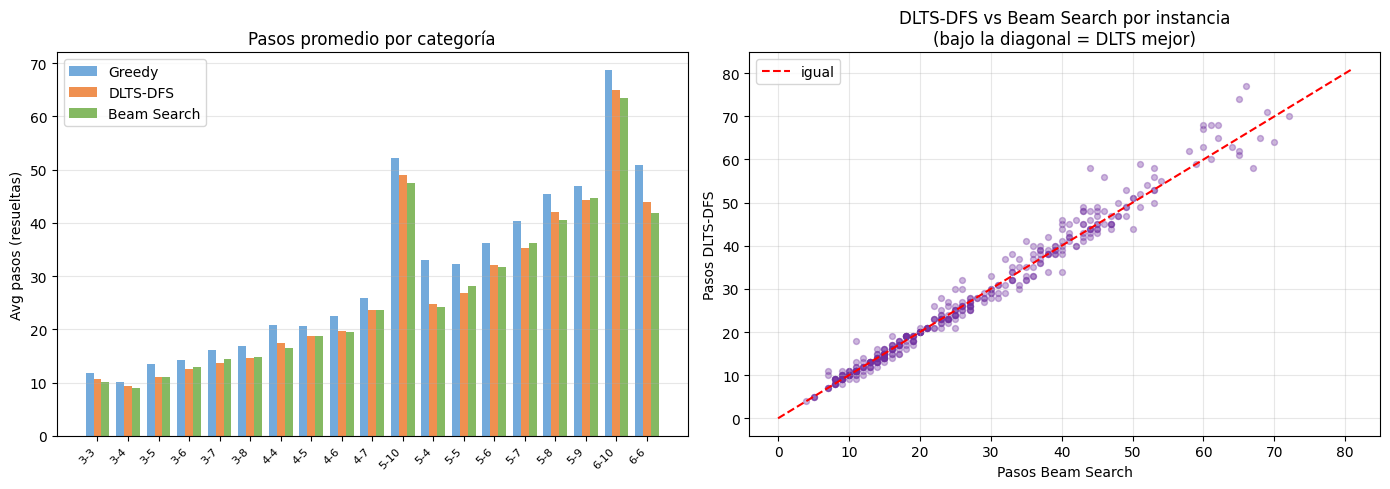

In [7]:
import matplotlib.pyplot as plt

cats_ok = [c for c in all_results if all_results[c]['s_g'] and all_results[c]['s_d']]
cats_sorted = sorted(cats_ok)

avg_g = [avg(all_results[c]['st_g'], all_results[c]['s_g']) for c in cats_sorted]
avg_d = [avg(all_results[c]['st_d'], all_results[c]['s_d']) for c in cats_sorted]
avg_b = [avg(all_results[c]['st_b'], all_results[c]['s_b']) for c in cats_sorted]

x = np.arange(len(cats_sorted))
width = 0.26

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Pasos promedio por categoría ─────────────────────────────────────────────
ax = axes[0]
ax.bar(x - width, avg_g, width, label='Greedy',      color='#5b9bd5', alpha=0.85)
ax.bar(x,         avg_d, width, label='DLTS-DFS',    color='#ed7d31', alpha=0.85)
ax.bar(x + width, avg_b, width, label='Beam Search', color='#70ad47', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(cats_sorted, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Avg pasos (resueltas)')
ax.set_title('Pasos promedio por categoría')
ax.legend(); ax.grid(axis='y', alpha=0.3)

# ── Scatter DLTS vs Beam (por instancia) ─────────────────────────────────────
steps_d_all = [s for r in all_results.values()
               for ok_d, ok_b, s in zip(r['s_d'], r['s_b'], r['st_d'])
               if ok_d and ok_b]
steps_b_all = [s for r in all_results.values()
               for ok_d, ok_b, s in zip(r['s_d'], r['s_b'], r['st_b'])
               if ok_d and ok_b]

ax2 = axes[1]
ax2.scatter(steps_b_all, steps_d_all, alpha=0.35, s=18, color='#7030a0')
mx = max(max(steps_d_all), max(steps_b_all)) * 1.05
ax2.plot([0, mx], [0, mx], 'r--', lw=1.5, label='igual')
ax2.set_xlabel('Pasos Beam Search')
ax2.set_ylabel('Pasos DLTS-DFS')
ax2.set_title('DLTS-DFS vs Beam Search por instancia\n(bajo la diagonal = DLTS mejor)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()